# Audio-Klassifikation mit drei Klassen: CNN, Hierarchie und Metric Learning

In diesem Notebook vergleichen wir mehrere Modellansatze fuer ein drei-Klassen-Audio-Problem, bei dem zwei Klassen stark aehnlich sind. Das Notebook ist bewusst modular aufgebaut und kann mit einem Standard-Ordner fuer Klassen direkt ausgefuehrt werden.

Verglichen werden:

- ein CNN auf Log-Mel-Spektrogrammen als Baseline
- ein hierarchisches Zwei-Stufen-Modell
- ein Metric-Learning-Ansatz mit Triplet Loss und Nearest-Centroid-Klassifikation
- ein optionaler Pretrained-Audio-Block, falls lokal verfuegbar

Wichtige Designziele:

- reproduzierbare Splits und Seeds
- einheitliche Trainingsparameter fuer faire Vergleiche
- klare Trennung in Daten, Features, Modelle, Training und Evaluation
- besonderes Augenmerk auf die Verwechslung der beiden aehnlichen Klassen B und C


## Ziel und Versuchsaufbau

Wir gehen von drei Klassen aus:

- `A`: gut unterscheidbare Klasse
- `B` und `C`: stark aehnliche Klassen

Das Notebook erwartet eine standardisierte Ordnerstruktur mit je einem Unterordner pro Klasse. Wenn im Projekt bereits eine `label_mapping.json` vorhanden ist, wird diese zur Bestimmung der Klassenreihenfolge genutzt. Falls kein passender Datensatz gefunden wird, erzeugt das Notebook automatisch ein kleines Demo-Set mit synthetischen WAV-Dateien, damit der gesamte Workflow trotzdem lauffaehig bleibt.


In [7]:
from __future__ import annotations

import copy
import json
import math
import random
import warnings
import wave
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

SEED = 42


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


@dataclass(frozen=True)
class AudioConfig:
    sample_rate: int = 16_000
    clip_seconds: float = 2.0
    n_fft: int = 1024
    hop_length: int = 320
    n_mels: int = 64
    f_min: int = 20
    f_max: int = 8_000
    time_mask_param: int = 14
    freq_mask_param: int = 8
    max_time_shift: float = 0.15


AUDIO = AudioConfig()
TARGET_SAMPLES = int(AUDIO.sample_rate * AUDIO.clip_seconds)
LABEL_ALIASES = ['A', 'B', 'C']
SIMILAR_CLASS_LABELS = ('B', 'C')
BASE_DIR = Path('data')
DEMO_DIR = Path('demo_audio_data')
LABEL_MAPPING_FILE = Path('label_mapping.json')
BATCH_SIZE = 32
MAX_EPOCHS = 18
PATIENCE = 5
LEARNING_RATE = 1e-3
EMBED_DIM = 64
NUM_WORKERS = 0
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RUN_OPTIONAL_PRETRAINED = False
AST_MODEL_ID = 'MIT/ast-finetuned-audioset-10-10-0.4593'

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9


Device: cpu


## Daten finden und vorbereiten

Die naechsten Zellen lesen die Klassenordner ein, nutzen wenn moeglich die vorhandene `label_mapping.json` und bauen daraus eine einheitliche Manifest-Tabelle. Wenn kein passender Datensatz gefunden wird, wird ein kleines synthetisches Demo-Set erzeugt, damit das Notebook lauffaehig bleibt.


In [8]:
def read_label_mapping(mapping_file: Path) -> List[str]:
    if not mapping_file.exists():
        return []
    try:
        raw = json.loads(mapping_file.read_text(encoding='utf-8'))
        ordered_keys = sorted(raw.keys(), key=lambda key: int(key))
        return [raw[key] for key in ordered_keys]
    except Exception:
        return []


def write_wav_pcm16(path: Path, waveform: np.ndarray, sample_rate: int) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    waveform = np.asarray(waveform, dtype=np.float32)
    if waveform.ndim == 1:
        waveform = waveform[np.newaxis, :]
    waveform = np.clip(waveform, -1.0, 1.0)
    pcm16 = (waveform * 32767.0).astype(np.int16)
    with wave.open(str(path), 'wb') as wf:
        wf.setnchannels(pcm16.shape[0])
        wf.setsampwidth(2)
        wf.setframerate(sample_rate)
        wf.writeframes(np.ascontiguousarray(pcm16.T).tobytes())


def synthesize_demo_wave(label_alias: str, index: int, config: AudioConfig) -> np.ndarray:
    sr = config.sample_rate
    n_samples = int(sr * config.clip_seconds)
    t = np.linspace(0.0, config.clip_seconds, n_samples, endpoint=False)
    rng = np.random.default_rng(SEED + index * 17 + ord(label_alias[0]))
    phase = rng.uniform(0.0, 2.0 * np.pi)
    envelope = np.hanning(n_samples)
    noise = 0.03 * rng.standard_normal(n_samples)

    if label_alias == 'A':
        base = 220 + 4 * (index % 5)
        signal = 0.80 * np.sin(2.0 * np.pi * base * t + phase)
        signal += 0.15 * np.sin(2.0 * np.pi * (base * 2.2) * t)
    elif label_alias == 'B':
        base = 440 + 3 * (index % 5)
        signal = 0.65 * np.sin(2.0 * np.pi * base * t + phase)
        signal += 0.22 * np.sin(2.0 * np.pi * (base * 2.0) * t)
        signal += 0.08 * np.sin(2.0 * np.pi * (base * 3.0) * t)
    else:
        base = 458 + 3 * (index % 5)
        signal = 0.62 * np.sin(2.0 * np.pi * base * t + phase)
        signal += 0.22 * np.sin(2.0 * np.pi * (base * 2.0) * t)
        signal += 0.08 * np.sin(2.0 * np.pi * (base * 3.0) * t)

    signal = (signal + noise) * (0.45 + 0.55 * envelope)
    peak = np.max(np.abs(signal))
    if peak > 0:
        signal = signal / peak
    return signal.astype(np.float32)


def generate_demo_dataset(root: Path, samples_per_class: int = 30) -> None:
    root.mkdir(parents=True, exist_ok=True)
    for label_alias in LABEL_ALIASES:
        class_dir = root / label_alias
        class_dir.mkdir(parents=True, exist_ok=True)
        existing = list(class_dir.glob('*.wav'))
        if existing:
            continue
        for idx in range(samples_per_class):
            wave_data = synthesize_demo_wave(label_alias, idx, AUDIO)
            file_path = class_dir / f'{label_alias.lower()}_{idx:03d}.wav'
            write_wav_pcm16(file_path, wave_data, AUDIO.sample_rate)


def discover_class_folders(data_root: Path) -> List[Path]:
    if not data_root.exists():
        return []

    mapping_order = read_label_mapping(LABEL_MAPPING_FILE)
    selected: List[Path] = []
    if mapping_order:
        for folder_name in mapping_order:
            candidate = data_root / folder_name
            if candidate.exists() and any(candidate.rglob('*.wav')):
                selected.append(candidate)
        if len(selected) == 3:
            return selected

    candidates = [p for p in data_root.iterdir() if p.is_dir() and any(p.rglob('*.wav'))]
    candidates = sorted(candidates, key=lambda path: path.name.lower())
    if len(candidates) >= 3:
        if len(candidates) > 3:
            warnings.warn('Mehr als drei Klassenordner gefunden. Es werden die ersten drei genutzt.')
        return candidates[:3]
    return []


def build_manifest(data_root: Path) -> Tuple[pd.DataFrame, Dict[str, str], List[Path]]:
    class_folders = discover_class_folders(data_root)
    if len(class_folders) != 3:
        return pd.DataFrame(), {}, []

    folder_to_alias = {folder.name: alias for folder, alias in zip(class_folders, LABEL_ALIASES)}
    rows = []
    for label_idx, folder in enumerate(class_folders):
        for wav_path in sorted(folder.rglob('*.wav')):
            rows.append(
                {
                    'path': wav_path,
                    'folder_name': folder.name,
                    'label_alias': LABEL_ALIASES[label_idx],
                    'label_idx': label_idx,
                }
            )

    frame = pd.DataFrame(rows)
    return frame, folder_to_alias, class_folders


manifest, folder_to_alias, class_folders = build_manifest(BASE_DIR)
if manifest.empty:
    print('Kein passender WAV-Datensatz in ./data gefunden. Erzeuge Demo-Daten in ./demo_audio_data ...')
    generate_demo_dataset(DEMO_DIR)
    manifest, folder_to_alias, class_folders = build_manifest(DEMO_DIR)

if manifest.empty:
    raise RuntimeError('Es konnte weder ein realer Datensatz noch ein Demo-Datensatz geladen werden.')

DISPLAY_CLASS_NAMES = [f'{alias} ({folder.name})' for alias, folder in zip(LABEL_ALIASES, class_folders)]
CLASS_TO_IDX = {alias: idx for idx, alias in enumerate(LABEL_ALIASES)}
IDX_TO_ALIAS = {idx: alias for alias, idx in CLASS_TO_IDX.items()}
IDX_TO_FOLDER = {idx: folder.name for idx, folder in enumerate(class_folders)}

manifest['label_idx'] = manifest['label_alias'].map(CLASS_TO_IDX)
manifest['path'] = manifest['path'].apply(Path)

print('Klassenreihenfolge:')
for idx, folder in enumerate(class_folders):
    print(f'  {LABEL_ALIASES[idx]} -> {folder.name}')

if len(manifest['label_idx'].unique()) != 3:
    raise RuntimeError('Der Datensatz muss genau drei Klassen enthalten.')

train_df, temp_df = train_test_split(
    manifest,
    test_size=(1.0 - TRAIN_RATIO),
    random_state=SEED,
    stratify=manifest['label_idx'],
)

relative_val_ratio = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
val_df, test_df = train_test_split(
    temp_df,
    test_size=(1.0 - relative_val_ratio),
    random_state=SEED,
    stratify=temp_df['label_idx'],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
display(pd.DataFrame({'alias': LABEL_ALIASES, 'folder': [folder.name for folder in class_folders]}))
display(manifest.head())


Klassenreihenfolge:
  A -> licht_an
  B -> licht_aus
  C -> unknown
Train: 324 | Val: 70 | Test: 70


,alias,folder
0,A,licht_an
1,B,licht_aus
2,C,unknown


,path,folder_name,label_alias,label_idx
0,data\licht_an\MiniMax_2026-05-05_16_43_17_Levi...,licht_an,A,0
1,data\licht_an\MiniMax_2026-05-05_16_43_17_Levi...,licht_an,A,0
2,data\licht_an\MiniMax_2026-05-05_16_43_17_Levi...,licht_an,A,0
3,data\licht_an\MiniMax_2026-05-05_16_43_17_Levi...,licht_an,A,0
4,data\licht_an\MiniMax_2026-05-05_16_43_17_Levi...,licht_an,A,0


## Erster Blick auf die Daten

Wir schauen uns die Klassenverteilung an und inspizieren exemplarisch ein Signal und sein Log-Mel-Spektrogramm.


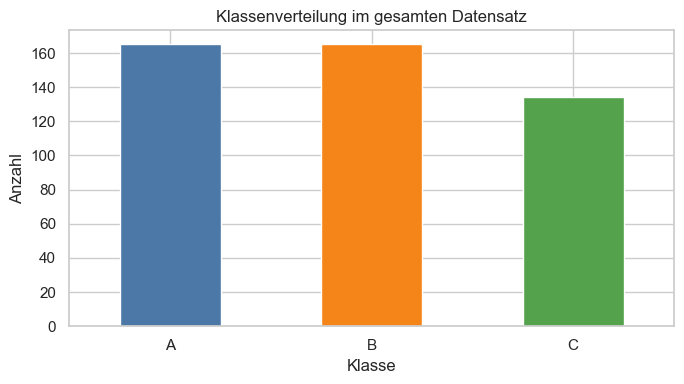

RuntimeError: Could not load libtorchcodec. Likely causes:
          1. FFmpeg is not properly installed in your environment. We support
             versions 4, 5, 6, 7, and 8, and we attempt to load libtorchcodec
             for each of those versions. Errors for versions not installed on
             your system are expected; only the error for your installed FFmpeg
             version is relevant. On Windows, ensure you've installed the
             "full-shared" version which ships DLLs.
          2. The PyTorch version (2.12.0+cpu) is not compatible with
             this version of TorchCodec. Refer to the version compatibility
             table:
             https://github.com/pytorch/torchcodec?tab=readme-ov-file#installing-torchcodec.
          3. Another runtime dependency; see exceptions below.

        The following exceptions were raised as we tried to load libtorchcodec:
        
[start of libtorchcodec loading traceback]
FFmpeg version 8:
Traceback (most recent call 

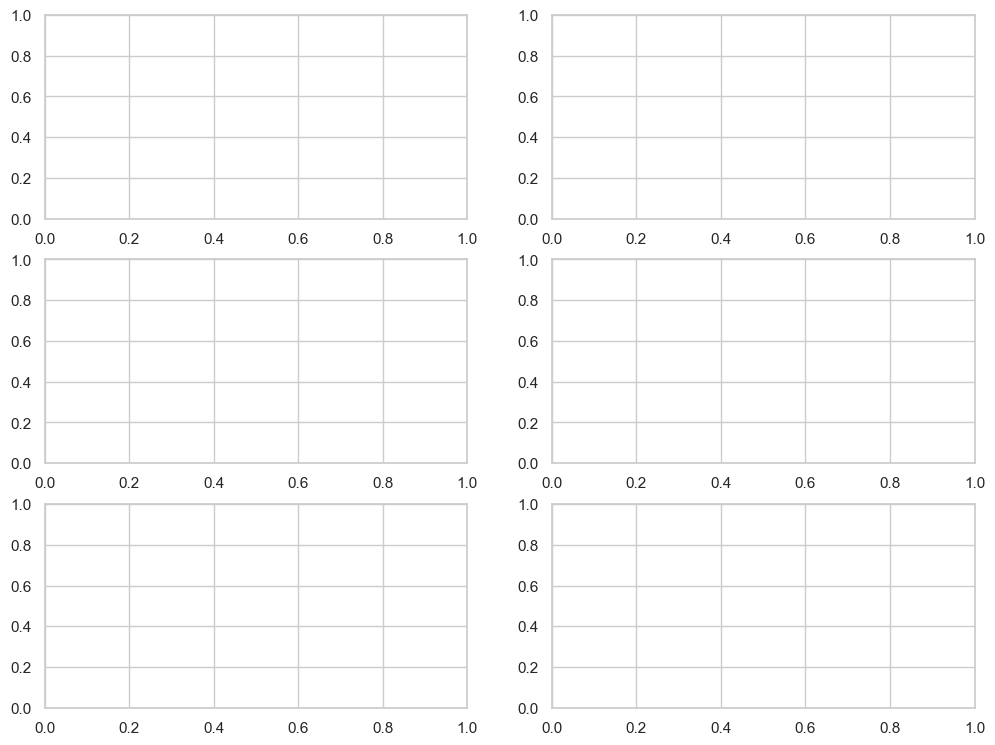

In [9]:
def plot_class_distribution(frame: pd.DataFrame, title: str) -> None:
    counts = frame['label_alias'].value_counts().reindex(LABEL_ALIASES)
    plt.figure(figsize=(7, 4))
    counts.plot(kind='bar', color=['#4C78A8', '#F58518', '#54A24B'])
    plt.title(title)
    plt.xlabel('Klasse')
    plt.ylabel('Anzahl')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


plot_class_distribution(manifest, 'Klassenverteilung im gesamten Datensatz')

example_rows = [manifest[manifest['label_alias'] == alias].iloc[0] for alias in LABEL_ALIASES]
fig, axes = plt.subplots(len(example_rows), 2, figsize=(12, 9))
for row_idx, row in enumerate(example_rows):
    waveform, sr = torchaudio.load(str(row['path']))
    waveform = waveform.mean(dim=0, keepdim=True)
    axes[row_idx, 0].plot(waveform.squeeze().numpy(), color='#1f77b4', linewidth=0.8)
    axes[row_idx, 0].set_title(f'Wellenform: {row["label_alias"]} / {row["folder_name"]}')
    axes[row_idx, 0].set_xlabel('Samples')
    axes[row_idx, 0].set_ylabel('Amplitude')

    mel = torchaudio.transforms.MelSpectrogram(
        sample_rate=AUDIO.sample_rate,
        n_fft=AUDIO.n_fft,
        hop_length=AUDIO.hop_length,
        n_mels=AUDIO.n_mels,
        f_min=AUDIO.f_min,
        f_max=AUDIO.f_max,
        power=2.0,
    )
    db = torchaudio.transforms.AmplitudeToDB(stype='power')
    if sr != AUDIO.sample_rate:
        waveform = torchaudio.transforms.Resample(sr, AUDIO.sample_rate)(waveform)
    if waveform.size(-1) < TARGET_SAMPLES:
        pad = TARGET_SAMPLES - waveform.size(-1)
        waveform = F.pad(waveform, (pad // 2, pad - pad // 2))
    else:
        waveform = waveform[..., :TARGET_SAMPLES]
    spec = db(mel(waveform)).squeeze().numpy()
    axes[row_idx, 1].imshow(spec, origin='lower', aspect='auto', cmap='magma')
    axes[row_idx, 1].set_title(f'Log-Mel: {row["label_alias"]} / {row["folder_name"]}')
    axes[row_idx, 1].set_xlabel('Zeit')
    axes[row_idx, 1].set_ylabel('Mel-Bins')

plt.tight_layout()
plt.show()


## Vorverarbeitung und Data Augmentation

Wir verwenden eine einheitliche Audio-Pipeline:

- Resampling auf eine feste Sample Rate
- Mono-Konvertierung
- Zentriertes Trimmen oder Padding auf eine feste Laenge
- Log-Mel-Spektrogramme als Eingabe fuer die Modelle
- Normalisierung ueber die Trainingsdaten
- Augmentation mit Time Shift, Frequency Masking und Time Masking


In [ ]:
RESAMPLERS: Dict[int, torchaudio.transforms.Resample] = {}
MEL_TRANSFORM = torchaudio.transforms.MelSpectrogram(
    sample_rate=AUDIO.sample_rate,
    n_fft=AUDIO.n_fft,
    hop_length=AUDIO.hop_length,
    n_mels=AUDIO.n_mels,
    f_min=AUDIO.f_min,
    f_max=AUDIO.f_max,
    power=2.0,
)
DB_TRANSFORM = torchaudio.transforms.AmplitudeToDB(stype='power')
TIME_MASK = torchaudio.transforms.TimeMasking(time_mask_param=AUDIO.time_mask_param)
FREQ_MASK = torchaudio.transforms.FrequencyMasking(freq_mask_param=AUDIO.freq_mask_param)


def get_resampler(orig_sample_rate: int) -> torchaudio.transforms.Resample:
    if orig_sample_rate not in RESAMPLERS:
        RESAMPLERS[orig_sample_rate] = torchaudio.transforms.Resample(orig_sample_rate, AUDIO.sample_rate)
    return RESAMPLERS[orig_sample_rate]


def pad_or_trim(waveform: torch.Tensor, target_samples: int = TARGET_SAMPLES) -> torch.Tensor:
    length = waveform.size(-1)
    if length > target_samples:
        start = (length - target_samples) // 2
        waveform = waveform[..., start : start + target_samples]
    elif length < target_samples:
        pad = target_samples - length
        left = pad // 2
        right = pad - left
        waveform = F.pad(waveform, (left, right))
    return waveform


def load_waveform(path: Path) -> Tuple[torch.Tensor, int]:
    waveform, sample_rate = torchaudio.load(str(path))
    waveform = waveform.float()
    if waveform.ndim == 1:
        waveform = waveform.unsqueeze(0)
    if waveform.size(0) > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    peak = waveform.abs().max().clamp(min=1e-6)
    waveform = waveform / peak
    if sample_rate != AUDIO.sample_rate:
        waveform = get_resampler(sample_rate)(waveform)
    waveform = pad_or_trim(waveform, TARGET_SAMPLES)
    return waveform, AUDIO.sample_rate


def random_time_shift(waveform: torch.Tensor, max_shift_fraction: float = AUDIO.max_time_shift) -> torch.Tensor:
    max_shift = int(max_shift_fraction * waveform.size(-1))
    if max_shift <= 0:
        return waveform
    shift = random.randint(-max_shift, max_shift)
    return torch.roll(waveform, shifts=shift, dims=-1)


def waveform_to_log_mel(waveform: torch.Tensor) -> torch.Tensor:
    return DB_TRANSFORM(MEL_TRANSFORM(waveform))


def normalize_feature(spec: torch.Tensor, stats: Optional[Dict[str, torch.Tensor]]) -> torch.Tensor:
    if stats is None:
        return spec
    return (spec - stats['mean']) / stats['std']


def extract_feature(path: Path, augment: bool = False, stats: Optional[Dict[str, torch.Tensor]] = None) -> torch.Tensor:
    waveform, _ = load_waveform(path)
    if augment and random.random() < 0.9:
        waveform = random_time_shift(waveform)
    spec = waveform_to_log_mel(waveform)
    if augment:
        spec = FREQ_MASK(spec)
        spec = TIME_MASK(spec)
    spec = normalize_feature(spec, stats)
    return spec


def compute_feature_stats(frame: pd.DataFrame, max_items: Optional[int] = None) -> Dict[str, torch.Tensor]:
    items = frame['path'].tolist()
    if max_items is not None:
        items = items[:max_items]

    total = 0.0
    total_sq = 0.0
    n_values = 0
    with torch.no_grad():
        for path in items:
            spec = extract_feature(path, augment=False, stats=None)
            total += spec.sum().item()
            total_sq += (spec ** 2).sum().item()
            n_values += spec.numel()
    mean = total / max(n_values, 1)
    variance = max(total_sq / max(n_values, 1) - mean**2, 1e-6)
    std = math.sqrt(variance)
    return {
        'mean': torch.tensor(mean, dtype=torch.float32),
        'std': torch.tensor(std, dtype=torch.float32),
    }


class AudioClassificationDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, augment: bool, stats: Dict[str, torch.Tensor], label_col: str = 'label_idx'):
        self.frame = frame.reset_index(drop=True)
        self.augment = augment
        self.stats = stats
        self.label_col = label_col

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]
        spec = extract_feature(Path(row['path']), augment=self.augment, stats=self.stats)
        label = torch.tensor(int(row[self.label_col]), dtype=torch.long)
        return spec, label, str(row['path'])


def make_loader(frame: pd.DataFrame, augment: bool, stats: Dict[str, torch.Tensor], batch_size: int = BATCH_SIZE, shuffle: bool = False, label_col: str = 'label_idx') -> DataLoader:
    dataset = AudioClassificationDataset(frame, augment=augment, stats=stats, label_col=label_col)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


FEATURE_STATS = compute_feature_stats(train_df)
print(f"Feature mean: {FEATURE_STATS['mean'].item():.4f} | std: {FEATURE_STATS['std'].item():.4f}")

train_loader = make_loader(train_df, augment=True, stats=FEATURE_STATS, shuffle=True)
val_loader = make_loader(val_df, augment=False, stats=FEATURE_STATS, shuffle=False)
test_loader = make_loader(test_df, augment=False, stats=FEATURE_STATS, shuffle=False)


In [ ]:
def show_preprocessed_example(frame: pd.DataFrame, title: str) -> None:
    row = frame.iloc[0]
    waveform, _ = load_waveform(Path(row['path']))
    raw_spec = waveform_to_log_mel(waveform).squeeze().numpy()
    aug_spec = extract_feature(Path(row['path']), augment=True, stats=FEATURE_STATS).squeeze().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(raw_spec, origin='lower', aspect='auto', cmap='magma')
    axes[0].set_title(f'Ohne Augmentation: {row["label_alias"]}')
    axes[0].set_xlabel('Zeit')
    axes[0].set_ylabel('Mel-Bins')

    axes[1].imshow(aug_spec, origin='lower', aspect='auto', cmap='magma')
    axes[1].set_title(f'Mit Augmentation: {row["label_alias"]}')
    axes[1].set_xlabel('Zeit')
    axes[1].set_ylabel('Mel-Bins')

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_preprocessed_example(train_df, 'Beispielhafte Vorverarbeitung')


## Modellfamilien

Alle Varianten nutzen dieselbe Vorverarbeitung. Damit werden Unterschiede im Ergebnis moeglichst auf den Modellansatz selbst zurueckgefuehrt.

Wir definieren:

- eine gemeinsame CNN-Basis
- eine allgemeine Trainings- und Evaluationslogik fuer Klassifikatoren
- Hilfsfunktionen fuer B/C-Verwechslungsanalyse


In [ ]:
class AudioCNNBackbone(nn.Module):
    def __init__(self, embedding_dim: int = EMBED_DIM):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.15),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, embedding_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.pool(x)
        return self.projection(x)


class AudioClassifier(nn.Module):
    def __init__(self, num_classes: int, embedding_dim: int = EMBED_DIM):
        super().__init__()
        self.backbone = AudioCNNBackbone(embedding_dim=embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x)
        return self.classifier(x)


class AudioEmbeddingNet(nn.Module):
    def __init__(self, embedding_dim: int = EMBED_DIM):
        super().__init__()
        self.backbone = AudioCNNBackbone(embedding_dim=embedding_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone(x)


def class_weights_from_frame(frame: pd.DataFrame, label_col: str = 'label_idx', num_classes: int = 3) -> torch.Tensor:
    counts = frame[label_col].value_counts().reindex(range(num_classes), fill_value=0).astype(float).values
    weights = len(frame) / (num_classes * np.clip(counts, 1.0, None))
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def summarize_predictions(y_true: Sequence[int], y_pred: Sequence[int], y_prob: Optional[np.ndarray] = None) -> Dict[str, float]:
    summary = {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }
    if y_prob is not None:
        try:
            y_true_bin = label_binarize(y_true, classes=list(range(y_prob.shape[1])))
            summary['roc_auc_ovr'] = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovr')
        except Exception:
            summary['roc_auc_ovr'] = float('nan')
    else:
        summary['roc_auc_ovr'] = float('nan')
    return summary


def run_classifier_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: Optional[torch.optim.Optimizer] = None,
) -> Dict[str, object]:
    training = optimizer is not None
    model.train(training)

    losses: List[float] = []
    y_true: List[int] = []
    y_pred: List[int] = []
    y_prob: List[np.ndarray] = []

    for specs, labels, _paths in loader:
        specs = specs.to(DEVICE)
        labels = labels.to(DEVICE)

        if training:
            optimizer.zero_grad(set_to_none=True)

        logits = model(specs)
        loss = criterion(logits, labels)

        if training:
            loss.backward()
            optimizer.step()

        probs = torch.softmax(logits.detach(), dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)

        losses.append(loss.detach().cpu().item())
        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.tolist())
        y_prob.append(probs)

    y_prob_np = np.concatenate(y_prob, axis=0) if y_prob else None
    metrics = summarize_predictions(y_true, y_pred, y_prob=y_prob_np)
    metrics['loss'] = float(np.mean(losses)) if losses else float('nan')
    metrics['y_true'] = np.array(y_true)
    metrics['y_pred'] = np.array(y_pred)
    metrics['y_prob'] = y_prob_np
    return metrics


class EarlyStopping:
    def __init__(self, patience: int = PATIENCE, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.best_state: Optional[Dict[str, torch.Tensor]] = None
        self.wait = 0

    def step(self, model: nn.Module, val_loss: float) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.wait = 0
            return False
        self.wait += 1
        return self.wait >= self.patience


def train_classifier_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    class_weights: torch.Tensor,
    max_epochs: int = MAX_EPOCHS,
    patience: int = PATIENCE,
    learning_rate: float = LEARNING_RATE,
) -> Tuple[nn.Module, pd.DataFrame]:
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    stopper = EarlyStopping(patience=patience)
    history_rows = []

    for epoch in range(1, max_epochs + 1):
        train_metrics = run_classifier_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_classifier_epoch(model, val_loader, criterion, optimizer=None)

        history_rows.append(
            {
                'epoch': epoch,
                'train_loss': train_metrics['loss'],
                'val_loss': val_metrics['loss'],
                'train_accuracy': train_metrics['accuracy'],
                'val_accuracy': val_metrics['accuracy'],
                'train_macro_f1': train_metrics['macro_f1'],
                'val_macro_f1': val_metrics['macro_f1'],
            }
        )

        print(
            f"Epoch {epoch:02d} | "
            f"train loss {train_metrics['loss']:.4f} | val loss {val_metrics['loss']:.4f} | "
            f"val macro F1 {val_metrics['macro_f1']:.4f}"
        )

        if stopper.step(model, float(val_metrics['loss'])):
            print('Early stopping ausgelost.')
            break

    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    return model, pd.DataFrame(history_rows)


def plot_training_history(history: pd.DataFrame, title: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['epoch'], history['train_loss'], label='Train')
    axes[0].plot(history['epoch'], history['val_loss'], label='Val')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoche')
    axes[0].legend()

    axes[1].plot(history['epoch'], history['train_macro_f1'], label='Train')
    axes[1].plot(history['epoch'], history['val_macro_f1'], label='Val')
    axes[1].set_title(f'{title} - Macro F1')
    axes[1].set_xlabel('Epoche')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm: np.ndarray, title: str, class_names: Sequence[str] = DISPLAY_CLASS_NAMES) -> None:
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Vorhersage')
    plt.ylabel('Wahr')
    plt.tight_layout()
    plt.show()


def bc_confusion_rate(cm: np.ndarray) -> float:
    idx_b = LABEL_ALIASES.index('B')
    idx_c = LABEL_ALIASES.index('C')
    denom = cm[idx_b].sum() + cm[idx_c].sum()
    if denom == 0:
        return float('nan')
    return float((cm[idx_b, idx_c] + cm[idx_c, idx_b]) / denom)


def print_classification_details(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> None:
    print(f'\n{name}')
    print(classification_report(y_true, y_pred, target_names=DISPLAY_CLASS_NAMES, zero_division=0))


## Baseline: CNN auf Log-Mel-Spektrogrammen

Das Baseline-Modell ist ein kompakter 2D-CNN-Klassifikator. Es ist bewusst klein gehalten, damit die Vergleiche zwischen den Ansatzen moeglichst fair bleiben und nicht nur die Modellgroesse entscheiden.


In [ ]:
baseline_model = AudioClassifier(num_classes=3).to(DEVICE)
base_weights = class_weights_from_frame(train_df, num_classes=3)
baseline_model, baseline_history = train_classifier_model(
    baseline_model,
    train_loader,
    val_loader,
    class_weights=base_weights,
)

plot_training_history(baseline_history, 'CNN-Baseline')

baseline_eval = run_classifier_epoch(
    baseline_model,
    test_loader,
    nn.CrossEntropyLoss(weight=base_weights),
    optimizer=None,
)

baseline_cm = confusion_matrix(baseline_eval['y_true'], baseline_eval['y_pred'], labels=[0, 1, 2])
plot_confusion_matrix(baseline_cm, 'Confusion Matrix - CNN-Baseline')
print_classification_details('CNN-Baseline Test-Report', baseline_eval['y_true'], baseline_eval['y_pred'])


## Hierarchisches Modell

Hier wird die Aufgabe in zwei Stufen zerlegt:

1. `A` vs. (`B` + `C`)
2. `B` vs. `C`

Die Endentscheidung wird aus beiden Modellen zusammengesetzt. Dieses Setup ist besonders interessant, wenn sich ein Teil der Klassen stark aehnelt, die andere Klasse aber deutlich separierbar ist.


In [ ]:
def remap_binary_frame(frame: pd.DataFrame, positive_alias: str, negative_aliases: Sequence[str]) -> pd.DataFrame:
    subset = frame[frame['label_alias'].isin([positive_alias, *negative_aliases])].copy().reset_index(drop=True)
    subset['label_idx'] = np.where(subset['label_alias'] == positive_alias, 0, 1)
    return subset


def collect_logits(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    y_true: List[int] = []
    logits_all: List[np.ndarray] = []
    with torch.no_grad():
        for specs, labels, _paths in loader:
            specs = specs.to(DEVICE)
            logits = model(specs).cpu().numpy()
            logits_all.append(logits)
            y_true.extend(labels.numpy().tolist())
    return np.concatenate(logits_all, axis=0), np.array(y_true)


def make_eval_loader(frame: pd.DataFrame, stats: Dict[str, torch.Tensor], label_col: str = 'label_idx') -> DataLoader:
    return make_loader(frame, augment=False, stats=stats, shuffle=False, label_col=label_col)


def hierarchical_predict(
    model_a_vs_rest: nn.Module,
    model_bc: nn.Module,
    frame: pd.DataFrame,
    stats: Dict[str, torch.Tensor],
    threshold: float,
) -> Tuple[np.ndarray, np.ndarray]:
    loader = make_eval_loader(frame, stats, label_col='label_idx')
    model_a_vs_rest.eval()
    model_bc.eval()

    y_true: List[int] = []
    y_pred: List[int] = []
    with torch.no_grad():
        for specs, labels, _paths in loader:
            specs = specs.to(DEVICE)
            logits_a = model_a_vs_rest(specs)
            logits_bc = model_bc(specs)
            prob_a = torch.softmax(logits_a, dim=1)[:, 0].cpu().numpy()
            pred_bc = torch.softmax(logits_bc, dim=1).cpu().numpy().argmax(axis=1)

            for idx in range(specs.size(0)):
                if prob_a[idx] >= threshold:
                    pred = 0
                else:
                    pred = 1 if pred_bc[idx] == 0 else 2
                y_pred.append(pred)
            y_true.extend(labels.numpy().tolist())

    return np.array(y_true), np.array(y_pred)


def tune_hierarchical_threshold(
    model_a_vs_rest: nn.Module,
    model_bc: nn.Module,
    frame: pd.DataFrame,
    stats: Dict[str, torch.Tensor],
) -> float:
    loader = make_eval_loader(frame, stats, label_col='label_idx')
    logits_a, y_true = collect_logits(model_a_vs_rest, loader)
    logits_bc, _ = collect_logits(model_bc, loader)
    prob_a = torch.softmax(torch.tensor(logits_a), dim=1)[:, 0].numpy()
    pred_bc = torch.softmax(torch.tensor(logits_bc), dim=1).numpy().argmax(axis=1)

    best_threshold = 0.5
    best_score = -1.0
    for threshold in np.linspace(0.1, 0.9, 41):
        preds = []
        for idx in range(len(y_true)):
            if prob_a[idx] >= threshold:
                preds.append(0)
            else:
                preds.append(1 if pred_bc[idx] == 0 else 2)
        score = f1_score(y_true, preds, average='macro', zero_division=0)
        if score > best_score:
            best_score = score
            best_threshold = float(threshold)

    print(f'Optimale Hierarchie-Schwelle aus Validation: {best_threshold:.2f} (Macro F1={best_score:.4f})')
    return best_threshold


train_a = remap_binary_frame(train_df, 'A', ['B', 'C'])
val_a = remap_binary_frame(val_df, 'A', ['B', 'C'])
test_a = remap_binary_frame(test_df, 'A', ['B', 'C'])

train_bc = remap_binary_frame(train_df, 'B', ['C'])
val_bc = remap_binary_frame(val_df, 'B', ['C'])
test_bc = remap_binary_frame(test_df, 'B', ['C'])

train_loader_a = make_loader(train_a, augment=True, stats=FEATURE_STATS, shuffle=True, label_col='label_idx')
val_loader_a = make_loader(val_a, augment=False, stats=FEATURE_STATS, shuffle=False, label_col='label_idx')
test_loader_a = make_loader(test_a, augment=False, stats=FEATURE_STATS, shuffle=False, label_col='label_idx')

train_loader_bc = make_loader(train_bc, augment=True, stats=FEATURE_STATS, shuffle=True, label_col='label_idx')
val_loader_bc = make_loader(val_bc, augment=False, stats=FEATURE_STATS, shuffle=False, label_col='label_idx')
test_loader_bc = make_loader(test_bc, augment=False, stats=FEATURE_STATS, shuffle=False, label_col='label_idx')

model_a = AudioClassifier(num_classes=2).to(DEVICE)
weights_a = class_weights_from_frame(train_a, num_classes=2)
model_a, history_a = train_classifier_model(model_a, train_loader_a, val_loader_a, class_weights=weights_a)

model_bc = AudioClassifier(num_classes=2).to(DEVICE)
weights_bc = class_weights_from_frame(train_bc, num_classes=2)
model_bc, history_bc = train_classifier_model(model_bc, train_loader_bc, val_loader_bc, class_weights=weights_bc)

plot_training_history(history_a, 'Hierarchie: A vs (B+C)')
plot_training_history(history_bc, 'Hierarchie: B vs C')

hier_threshold = tune_hierarchical_threshold(model_a, model_bc, val_df, FEATURE_STATS)
y_true_h, y_pred_h = hierarchical_predict(model_a, model_bc, test_df, FEATURE_STATS, threshold=hier_threshold)
hier_cm = confusion_matrix(y_true_h, y_pred_h, labels=[0, 1, 2])
plot_confusion_matrix(hier_cm, 'Confusion Matrix - Hierarchisches Modell')
print_classification_details('Hierarchisches Modell Test-Report', y_true_h, y_pred_h)


## Metric Learning mit Triplet Loss

Im Metric-Learning-Ansatz lernt das Modell nicht direkt eine Softmax-Klassifikation, sondern einen Embedding-Raum. Die Klassifikation erfolgt anschliessend im Embedding-Space, hier mit Nearest Centroid.

Das ist besonders spannend, wenn zwei Klassen sehr aehnlich sind: Das Modell kann lernen, deren Abstand im Embedding-Raum gezielt zu vergroessern.


In [ ]:
def build_triplets(frame: pd.DataFrame) -> List[Tuple[int, int, int]]:
    frame = frame.reset_index(drop=True)
    rng = random.Random(SEED)
    class_to_indices = {
        label: frame.index[frame['label_idx'] == label].tolist()
        for label in sorted(frame['label_idx'].unique())
    }
    triplets: List[Tuple[int, int, int]] = []
    for anchor_idx, row in frame.iterrows():
        label = int(row['label_idx'])
        positives = [idx for idx in class_to_indices[label] if idx != anchor_idx]
        negatives = [idx for other_label, idxs in class_to_indices.items() if other_label != label for idx in idxs]
        if not positives or not negatives:
            continue
        triplets.append((anchor_idx, rng.choice(positives), rng.choice(negatives)))
    rng.shuffle(triplets)
    return triplets


class TripletAudioDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, triplets: List[Tuple[int, int, int]], stats: Dict[str, torch.Tensor], augment: bool = True):
        self.frame = frame.reset_index(drop=True)
        self.triplets = triplets
        self.stats = stats
        self.augment = augment

    def __len__(self) -> int:
        return len(self.triplets)

    def _load_item(self, idx: int) -> Tuple[torch.Tensor, int]:
        row = self.frame.iloc[idx]
        spec = extract_feature(Path(row['path']), augment=self.augment, stats=self.stats)
        label = int(row['label_idx'])
        return spec, label

    def __getitem__(self, idx: int):
        anchor_idx, pos_idx, neg_idx = self.triplets[idx]
        anchor, anchor_label = self._load_item(anchor_idx)
        positive, _ = self._load_item(pos_idx)
        negative, _ = self._load_item(neg_idx)
        return anchor, positive, negative, torch.tensor(anchor_label, dtype=torch.long)


class TripletMiningLoss(nn.Module):
    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.loss = nn.TripletMarginLoss(margin=margin, p=2)

    def forward(self, anchor: torch.Tensor, positive: torch.Tensor, negative: torch.Tensor) -> torch.Tensor:
        anchor = F.normalize(anchor, dim=1)
        positive = F.normalize(positive, dim=1)
        negative = F.normalize(negative, dim=1)
        return self.loss(anchor, positive, negative)


def run_triplet_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: Optional[torch.optim.Optimizer] = None,
) -> Dict[str, object]:
    training = optimizer is not None
    model.train(training)
    losses: List[float] = []

    for anchor, positive, negative, _labels in loader:
        anchor = anchor.to(DEVICE)
        positive = positive.to(DEVICE)
        negative = negative.to(DEVICE)

        if training:
            optimizer.zero_grad(set_to_none=True)

        emb_a = model(anchor)
        emb_p = model(positive)
        emb_n = model(negative)
        loss = criterion(emb_a, emb_p, emb_n)

        if training:
            loss.backward()
            optimizer.step()

        losses.append(loss.detach().cpu().item())

    return {'loss': float(np.mean(losses)) if losses else float('nan')}


class TripletEarlyStopping:
    def __init__(self, patience: int = PATIENCE, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.best_state: Optional[Dict[str, torch.Tensor]] = None
        self.wait = 0

    def step(self, model: nn.Module, val_loss: float) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.wait = 0
            return False
        self.wait += 1
        return self.wait >= self.patience


def train_metric_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    max_epochs: int = MAX_EPOCHS,
    patience: int = PATIENCE,
    learning_rate: float = LEARNING_RATE,
) -> Tuple[nn.Module, pd.DataFrame]:
    criterion = TripletMiningLoss(margin=1.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    stopper = TripletEarlyStopping(patience=patience)
    history_rows = []

    for epoch in range(1, max_epochs + 1):
        train_metrics = run_triplet_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_triplet_epoch(model, val_loader, criterion, optimizer=None)
        history_rows.append({'epoch': epoch, 'train_loss': train_metrics['loss'], 'val_loss': val_metrics['loss']})
        print(f"Epoch {epoch:02d} | train triplet loss {train_metrics['loss']:.4f} | val triplet loss {val_metrics['loss']:.4f}")
        if stopper.step(model, float(val_metrics['loss'])):
            print('Early stopping ausgelost.')
            break

    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    return model, pd.DataFrame(history_rows)


def plot_triplet_history(history: pd.DataFrame, title: str) -> None:
    plt.figure(figsize=(6, 4))
    plt.plot(history['epoch'], history['train_loss'], label='Train')
    plt.plot(history['epoch'], history['val_loss'], label='Val')
    plt.title(title)
    plt.xlabel('Epoche')
    plt.ylabel('Triplet Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()


def extract_embeddings(model: nn.Module, frame: pd.DataFrame, stats: Dict[str, torch.Tensor]) -> Tuple[torch.Tensor, torch.Tensor]:
    loader = make_eval_loader(frame, stats, label_col='label_idx')
    model.eval()
    embeddings: List[torch.Tensor] = []
    labels: List[torch.Tensor] = []
    with torch.no_grad():
        for specs, batch_labels, _paths in loader:
            specs = specs.to(DEVICE)
            emb = F.normalize(model(specs), dim=1).cpu()
            embeddings.append(emb)
            labels.append(batch_labels.cpu())
    return torch.cat(embeddings, dim=0), torch.cat(labels, dim=0)


def fit_centroids(embeddings: torch.Tensor, labels: torch.Tensor, num_classes: int = 3) -> torch.Tensor:
    centroids = []
    for class_idx in range(num_classes):
        class_embeddings = embeddings[labels == class_idx]
        if len(class_embeddings) == 0:
            raise RuntimeError(f'Keine Embeddings fuer Klasse {class_idx} gefunden.')
        centroids.append(class_embeddings.mean(dim=0))
    return torch.stack(centroids, dim=0)


def predict_nearest_centroid(embeddings: torch.Tensor, centroids: torch.Tensor) -> torch.Tensor:
    distances = torch.cdist(embeddings, centroids)
    return distances.argmin(dim=1)


def evaluate_metric_model(
    model: nn.Module,
    train_frame: pd.DataFrame,
    eval_frame: pd.DataFrame,
    stats: Dict[str, torch.Tensor],
) -> Tuple[np.ndarray, np.ndarray, torch.Tensor]:
    train_emb, train_labels = extract_embeddings(model, train_frame, stats)
    centroids = fit_centroids(train_emb, train_labels, num_classes=3)
    eval_emb, eval_labels = extract_embeddings(model, eval_frame, stats)
    eval_pred = predict_nearest_centroid(eval_emb, centroids)
    return eval_labels.numpy(), eval_pred.numpy(), centroids


train_triplets = build_triplets(train_df)
val_triplets = build_triplets(val_df)

metric_train_ds = TripletAudioDataset(train_df, train_triplets, FEATURE_STATS, augment=True)
metric_val_ds = TripletAudioDataset(val_df, val_triplets, FEATURE_STATS, augment=False)
metric_train_loader = DataLoader(metric_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
metric_val_loader = DataLoader(metric_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

metric_model = AudioEmbeddingNet(embedding_dim=EMBED_DIM).to(DEVICE)
metric_model, metric_history = train_metric_model(metric_model, metric_train_loader, metric_val_loader)
plot_triplet_history(metric_history, 'Metric Learning - Triplet Loss')

metric_y_true, metric_y_pred, metric_centroids = evaluate_metric_model(metric_model, train_df, test_df, FEATURE_STATS)
metric_cm = confusion_matrix(metric_y_true, metric_y_pred, labels=[0, 1, 2])
plot_confusion_matrix(metric_cm, 'Confusion Matrix - Metric Learning')
print_classification_details('Metric Learning Test-Report', metric_y_true, metric_y_pred)


## Optional: Pretrained Audio Model

Dieser Abschnitt ist bewusst optional. Falls lokal bereits ein Pretrained-Audio-Modell verfuegbar ist, kann es hier geladen und experimentell mit denselben Splits feinjustiert werden. Wenn die Gewichte nicht lokal verfuegbar sind, wird der Block sauber uebersprungen, ohne dass der Rest des Notebooks betroffen ist.


In [ ]:
ast_model = None
ast_processor = None

if RUN_OPTIONAL_PRETRAINED:
    try:
        from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

        ast_processor = AutoFeatureExtractor.from_pretrained(AST_MODEL_ID, local_files_only=True)
        ast_model = AutoModelForAudioClassification.from_pretrained(
            AST_MODEL_ID,
            local_files_only=True,
            num_labels=3,
            ignore_mismatched_sizes=True,
        ).to(DEVICE)
        print('Pretrained AST-Modell lokal geladen.')
    except Exception as exc:
        ast_model = None
        ast_processor = None
        print(f'Optionaler Pretrained-Block wurde uebersprungen: {exc}')
else:
    print('Optionaler Pretrained-Block ist deaktiviert. Setze RUN_OPTIONAL_PRETRAINED = True, wenn lokal verfügbare Gewichte getestet werden sollen.')

print('Hinweis: Wenn du dieses Modell aktivieren willst, kannst du denselben Daten-Split und ein Waveform-Dataset verwenden.')


## Vergleich der Modellansaetze

Jetzt tragen wir alle Ergebnisse in eine gemeinsame Tabelle ein und vergleichen die wichtigsten Metriken.

Bewertet werden:

- Accuracy
- Macro F1
- optional ROC AUC OVR, falls sinnvoll verfuegbar
- Verwechslungsrate zwischen B und C
- Confusion Matrices als visuelle Diagnose


In [ ]:
results_records = []
confusion_matrices: Dict[str, np.ndarray] = {}

results_records.append(
    {
        'model': 'CNN-Baseline',
        **summarize_predictions(baseline_eval['y_true'], baseline_eval['y_pred'], baseline_eval['y_prob']),
        'bc_confusion_rate': bc_confusion_rate(baseline_cm),
    }
)
confusion_matrices['CNN-Baseline'] = baseline_cm

results_records.append(
    {
        'model': 'Hierarchisches Modell',
        **summarize_predictions(y_true_h, y_pred_h, None),
        'bc_confusion_rate': bc_confusion_rate(hier_cm),
    }
)
confusion_matrices['Hierarchisches Modell'] = hier_cm

results_records.append(
    {
        'model': 'Metric Learning',
        **summarize_predictions(metric_y_true, metric_y_pred, None),
        'bc_confusion_rate': bc_confusion_rate(metric_cm),
    }
)
confusion_matrices['Metric Learning'] = metric_cm

if ast_model is not None:
    results_records.append(
        {
            'model': 'Optional Pretrained',
            'accuracy': float('nan'),
            'macro_f1': float('nan'),
            'roc_auc_ovr': float('nan'),
            'bc_confusion_rate': float('nan'),
        }
    )

results_df = pd.DataFrame(results_records).sort_values('macro_f1', ascending=False, na_position='last').reset_index(drop=True)
display(results_df)

metric_cols = ['accuracy', 'macro_f1', 'bc_confusion_rate']
results_df.set_index('model')[['accuracy', 'macro_f1']].plot(kind='bar', figsize=(10, 4), color=['#4C78A8', '#F58518'])
plt.ylim(0.0, 1.05)
plt.title('Modellvergleich: Accuracy und Macro F1')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(confusion_matrices), figsize=(6 * len(confusion_matrices), 5))
if len(confusion_matrices) == 1:
    axes = [axes]
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=DISPLAY_CLASS_NAMES, yticklabels=DISPLAY_CLASS_NAMES, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Vorhersage')
    ax.set_ylabel('Wahr')
plt.tight_layout()
plt.show()

best_row = results_df.iloc[0]
print(f"Bestes Modell nach Macro F1: {best_row['model']} (Macro F1={best_row['macro_f1']:.4f}, Accuracy={best_row['accuracy']:.4f})")

baseline_bc = results_df.loc[results_df['model'] == 'CNN-Baseline', 'bc_confusion_rate'].iloc[0]
hier_bc = results_df.loc[results_df['model'] == 'Hierarchisches Modell', 'bc_confusion_rate'].iloc[0]
metric_bc = results_df.loc[results_df['model'] == 'Metric Learning', 'bc_confusion_rate'].iloc[0]

print('\nKurze Analyse:')
print(f'- CNN-Baseline B/C-Verwechslung: {baseline_bc:.4f}')
print(f'- Hierarchisches Modell B/C-Verwechslung: {hier_bc:.4f}')
print(f'- Metric Learning B/C-Verwechslung: {metric_bc:.4f}')

if np.isfinite(baseline_bc) and np.isfinite(hier_bc) and hier_bc < baseline_bc:
    print('- Die hierarchische Zerlegung reduziert hier die Verwechslung zwischen B und C.')
elif np.isfinite(baseline_bc) and np.isfinite(metric_bc) and metric_bc < baseline_bc:
    print('- Das Embedding-basierte Metric Learning reduziert hier die Verwechslung zwischen B und C.')
else:
    print('- Die B/C-Verwechslung bleibt ein kritischer Fehlerfall und sollte weiter analysiert werden.')


## Fazit

Dieses Notebook liefert eine komplette, wiederverwendbare Vergleichsstruktur fuer Audio-Klassifikation mit drei Klassen. Es eignet sich als Grundlage fuer reale Datensaetze mit einer aehnlichen Klassenstruktur und kann bei Bedarf leicht erweitert werden, zum Beispiel durch:

- spaetere Ablationen bei Augmentation und Clip-Laenge
- Transfer Learning mit einem lokal verfuegbaren Pretrained-Modell
- weitere Metriken wie per-class Recall oder Calibration
- eine feinere Analyse der Fehler zwischen den stark aehnlichen Klassen B und C
